# IMDB 영화 리뷰 감성분석 LSTM — 최신 PyTorch 코드

이 노트북은 영화 리뷰 문장을 입력받아 긍정/부정을 분류하는 LSTM 기반 이진 분류 예제입니다.

구성은 다음과 같습니다.

1. 실행 환경 확인
2. 라이브러리 불러오기
3. 하이퍼파라미터 설정
4. IMDB 데이터 준비
5. 단어 사전 확인과 리뷰 복원
6. PyTorch Dataset / DataLoader 구성
7. LSTM 모델 설계
8. 손실함수와 최적화 알고리즘 설명
9. 모델 학습
10. 모델 평가
11. 샘플 리뷰 예측 확인
12. 모델 저장과 불러오기


In [1]:
# PyTorch의 핵심 패키지입니다. 텐서 연산, GPU 연산, 신경망 학습의 기본 기능을 제공합니다.
import torch

# torch.nn은 신경망 계층, 손실함수, 활성화 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 AdamW, SGD 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# Dataset은 사용자 정의 데이터셋을 만들 때 상속받는 기본 클래스입니다.
# DataLoader는 데이터를 미니배치 단위로 모델에 공급하는 도구입니다.
from torch.utils.data import Dataset, DataLoader

# numpy는 배열 처리와 데이터 변환에 사용합니다.
import numpy as np

# matplotlib은 학습 손실과 정확도 그래프를 그리는 데 사용합니다.
import matplotlib.pyplot as plt

# sklearn.metrics는 혼동행렬, F1 점수, 정확도 계산에 사용합니다.
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

# time은 학습 시간을 측정하는 데 사용합니다.
from time import time

# os는 운영체제에 따라 DataLoader 작업자 수를 안전하게 설정하는 데 사용합니다.
import os

# IMDB 데이터셋 로더와 pad_sequences만 사용합니다.
# 모델 학습과 신경망 구현은 PyTorch로만 작성합니다.
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 현재 PyTorch 버전을 출력합니다.
print("PyTorch version:", torch.__version__)

# GPU 사용 가능 여부를 출력합니다.
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
CUDA available: False


## 1. 하이퍼파라미터 설정

하이퍼파라미터는 모델 학습 전에 사람이 직접 정하는 값입니다.

이 예제에서는 리뷰 문장을 숫자 시퀀스로 바꾸고, LSTM이 순서 정보를 학습하도록 구성합니다.


In [4]:
# 실험 결과를 최대한 재현 가능하게 만들기 위해 난수 시드를 고정합니다.
SEED = 111

# PyTorch CPU 연산의 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# GPU가 있는 경우 GPU 난수 시드도 고정합니다.
torch.cuda.manual_seed_all(SEED)

# 사용할 최대 단어 개수입니다. 가장 자주 등장하는 상위 10000개 단어만 사용합니다.
NUM_WORDS = 10000

# 각 영화 리뷰의 최대 길이입니다. 길이가 80보다 길면 자르고, 짧으면 0으로 채웁니다.
MAX_LEN = 80

# 단어 하나를 몇 차원 벡터로 표현할지 정합니다.
EMBED_DIM = 30

# LSTM 은닉 상태의 차원 수입니다.
HIDDEN_DIM = 100

# LSTM 계층 수입니다.
NUM_LAYERS = 1

# 학습 반복 횟수입니다. 실습 시간을 고려해 기본값은 10으로 설정했습니다.
EPOCHS = 10

# 한 번에 모델에 입력할 리뷰 개수입니다.
BATCH_SIZE = 128

# 학습률입니다.
LEARNING_RATE = 0.001

# Dropout 비율입니다. 과적합을 줄이기 위해 일부 뉴런을 무작위로 비활성화합니다.
DROPOUT = 0.3

# GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Windows 환경에서 DataLoader 오류를 줄이기 위해 작업자 수를 조절합니다.
NUM_WORKERS = 2 if os.name != "nt" else 0

# GPU 사용 시 데이터를 더 빠르게 복사할 수 있도록 설정합니다.
PIN_MEMORY = True if torch.cuda.is_available() else False

# 현재 사용할 장치를 출력합니다.
print("사용 장치:", device)

사용 장치: cpu


## 2. 데이터 준비

IMDB 영화 리뷰 데이터셋은 영화 리뷰 문장과 감성 라벨로 구성됩니다.

- 입력 데이터: 단어가 숫자로 바뀐 리뷰 문장
- 출력 데이터: 감성 라벨
  - `0`: 부정 리뷰
  - `1`: 긍정 리뷰

리뷰마다 길이가 다르므로 LSTM에 넣기 전에 같은 길이로 맞춥니다.


In [5]:
# IMDB 데이터셋을 불러옵니다.
# num_words=NUM_WORDS는 가장 자주 등장하는 상위 NUM_WORDS개 단어만 사용한다는 의미입니다.
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

# 원본 학습 입력 데이터의 모양을 출력합니다.
print("학습용 입력 데이터 모양:", X_train.shape)

# 원본 학습 정답 데이터의 모양을 출력합니다.
print("학습용 정답 데이터 모양:", y_train.shape)

# 원본 평가 입력 데이터의 모양을 출력합니다.
print("평가용 입력 데이터 모양:", X_test.shape)

# 원본 평가 정답 데이터의 모양을 출력합니다.
print("평가용 정답 데이터 모양:", y_test.shape)

# 첫 번째 리뷰의 숫자 시퀀스를 출력합니다.
print("첫 번째 영화 리뷰 숫자 시퀀스:")
print(X_train[0])

# 첫 번째 리뷰의 단어 개수를 출력합니다.
print("첫 번째 리뷰 단어 수:", len(X_train[0]))

# 첫 번째 리뷰의 정답 라벨을 출력합니다.
print("첫 번째 리뷰 감성 라벨:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
학습용 입력 데이터 모양: (25000,)
학습용 정답 데이터 모양: (25000,)
평가용 입력 데이터 모양: (25000,)
평가용 정답 데이터 모양: (25000,)
첫 번째 영화 리뷰 숫자 시퀀스:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 

In [7]:
# 첫 10개 리뷰의 길이를 출력하는 함수를 정의합니다.
def show_review_lengths(data, title):
    # 출력 제목을 표시합니다.
    print(title)

    # 앞에서부터 10개 리뷰를 확인합니다.
    for i in range(10):
        # i번째 리뷰의 길이를 출력합니다.
        print(f"리뷰 {i}: {len(data[i])}개 단어")

# 길이 정리 전 학습 데이터의 리뷰 길이를 확인합니다.
show_review_lengths(X_train, "길이 정리 전 첫 10개 리뷰 길이")

길이 정리 전 첫 10개 리뷰 길이
리뷰 0: 218개 단어
리뷰 1: 189개 단어
리뷰 2: 141개 단어
리뷰 3: 550개 단어
리뷰 4: 147개 단어
리뷰 5: 43개 단어
리뷰 6: 123개 단어
리뷰 7: 562개 단어
리뷰 8: 233개 단어
리뷰 9: 130개 단어


In [9]:
# 리뷰 길이를 MAX_LEN으로 통일합니다.
# truncating='post'는 길이가 긴 리뷰의 뒤쪽을 자른다는 의미입니다.
# padding='post'는 길이가 짧은 리뷰의 뒤쪽을 0으로 채운다는 의미입니다.
X_train = pad_sequences(X_train, maxlen=MAX_LEN, truncating="post", padding="post")

# 평가 데이터도 학습 데이터와 같은 방식으로 길이를 맞춥니다.
X_test = pad_sequences(X_test, maxlen=MAX_LEN, truncating="post", padding="post")

# 길이 정리 후 학습 데이터의 리뷰 길이를 확인합니다.
show_review_lengths(X_train, "길이 정리 후 첫 10개 리뷰 길이")

# 길이 정리 후 최종 데이터 모양을 출력합니다.
print("학습 입력 최종 모양:", X_train.shape)
print("평가 입력 최종 모양:", X_test.shape)

길이 정리 후 첫 10개 리뷰 길이
리뷰 0: 80개 단어
리뷰 1: 80개 단어
리뷰 2: 80개 단어
리뷰 3: 80개 단어
리뷰 4: 80개 단어
리뷰 5: 80개 단어
리뷰 6: 80개 단어
리뷰 7: 80개 단어
리뷰 8: 80개 단어
리뷰 9: 80개 단어
학습 입력 최종 모양: (25000, 80)
평가 입력 최종 모양: (25000, 80)


## 3. 단어 사전 확인과 리뷰 문장 복원

IMDB 데이터셋의 리뷰는 실제 단어가 아니라 숫자로 저장되어 있습니다.

숫자 시퀀스를 사람이 읽기 쉬운 단어로 되돌려 보면 데이터 구조를 이해하는 데 도움이 됩니다.


In [10]:
# 단어를 숫자로 바꿔주는 원본 사전을 불러옵니다.
word_to_id = imdb.get_word_index()

# 숫자를 단어로 바꿔주는 반대 사전을 만듭니다.
id_to_word = {value: key for key, value in word_to_id.items()}

# 전체 단어 사전 크기를 출력합니다.
print("전체 단어 사전 크기:", len(word_to_id))

# 특정 단어가 몇 번째 번호인지 확인합니다.
print("단어 'virus'의 번호:", word_to_id.get("virus"))

# 특정 번호가 어떤 단어인지 확인합니다.
print("3310번 단어:", id_to_word.get(3310))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
전체 단어 사전 크기: 88584
단어 'virus'의 번호: 3310
3310번 단어: virus


In [12]:
# 숫자로 된 리뷰를 단어로 복원하는 함수를 정의합니다.
def decode_review(encoded_review, id_to_word):
    # 복원된 단어들을 저장할 리스트를 만듭니다.
    decoded_words = []

    # 리뷰 안의 숫자 토큰을 하나씩 반복합니다.
    for token_id in encoded_review:
        # 0은 패딩 값이므로 <PAD>로 표시합니다.
        if token_id == 0:
            decoded_words.append("<PAD>")
        else:
            # IMDB 데이터셋은 특수 토큰 때문에 실제 단어 인덱스와 3 정도 차이가 있습니다.
            decoded_words.append(id_to_word.get(token_id - 3, "???"))

    # 단어 리스트를 공백으로 연결하여 하나의 문자열로 반환합니다.
    return " ".join(decoded_words)

# 첫 번째 학습 리뷰를 단어 형태로 복원합니다.
decoded_text = decode_review(X_train[0], id_to_word)

# 복원된 리뷰를 출력합니다.
print("첫 번째 리뷰 복원 결과:")
print(decoded_text)

# 첫 번째 리뷰의 정답 라벨을 출력합니다.
print("정답 라벨:", y_train[0], "(0=부정, 1=긍정)")

첫 번째 리뷰 복원 결과:
??? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ??? is an amazing actor and now the same being director ??? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as
정답 라벨: 1 (0=부정, 1=긍정)


## 4. PyTorch Dataset / DataLoader 구성

PyTorch에서는 데이터를 `Dataset`과 `DataLoader`로 관리하는 것이 일반적입니다.

`Dataset`은 데이터 한 개를 어떻게 꺼낼지 정의합니다.  
`DataLoader`는 Dataset에서 데이터를 가져와 미니배치로 묶어 모델에 전달합니다.


In [13]:
# 영화 리뷰 데이터셋을 PyTorch Dataset 형태로 정의합니다.
class IMDBReviewDataset(Dataset):
    # 데이터셋을 초기화하는 메서드입니다.
    def __init__(self, texts, labels):
        # 리뷰 숫자 시퀀스를 long 타입 텐서로 변환합니다.
        # Embedding 계층은 정수 인덱스를 입력으로 받기 때문에 long 타입이 필요합니다.
        self.texts = torch.tensor(texts, dtype=torch.long)

        # 정답 라벨을 float 타입 텐서로 변환합니다.
        # BCEWithLogitsLoss는 이진 분류에서 float 라벨을 사용합니다.
        self.labels = torch.tensor(labels, dtype=torch.float32)

    # 데이터셋의 전체 샘플 개수를 반환합니다.
    def __len__(self):
        return len(self.texts)

    # 특정 인덱스의 샘플 하나를 반환합니다.
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

# 학습용 Dataset을 생성합니다.
train_dataset = IMDBReviewDataset(X_train, y_train)

# 평가용 Dataset을 생성합니다.
test_dataset = IMDBReviewDataset(X_test, y_test)

# 학습용 DataLoader를 생성합니다.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# 평가용 DataLoader를 생성합니다.
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# 첫 번째 배치를 꺼내 데이터 모양을 확인합니다.
batch_texts, batch_labels = next(iter(train_loader))
print("배치 입력 모양:", batch_texts.shape)
print("배치 라벨 모양:", batch_labels.shape)

배치 입력 모양: torch.Size([128, 80])
배치 라벨 모양: torch.Size([128])


## 5. 모델 설계 상세 설명

이 모델은 영화 리뷰 문장의 순서 정보를 학습하기 위해 LSTM을 사용합니다.

### 5.1 입력 데이터 구조

각 리뷰는 단어가 숫자로 바뀐 시퀀스입니다. 배치로 묶이면 입력 모양은 `[배치크기, 문장길이]`입니다. 이 노트북에서는 문장길이를 `80`으로 맞춥니다.

### 5.2 Embedding 계층

숫자 자체에는 단어의 의미가 들어 있지 않습니다. `Embedding` 계층은 각 단어 번호를 의미를 가진 벡터로 바꿉니다. 입력 모양이 `[128, 80]`이면 임베딩 후 모양은 `[128, 80, 30]`입니다.

### 5.3 LSTM 계층

LSTM은 순서가 있는 데이터를 처리하는 순환 신경망 구조입니다. 리뷰 문장은 단어 순서에 따라 의미가 달라질 수 있으므로 LSTM이 적합합니다.

### 5.4 Dropout 계층

Dropout은 학습 중 일부 뉴런을 무작위로 꺼서 과적합을 줄입니다.

### 5.5 출력층

이 문제는 긍정/부정을 구분하는 이진 분류입니다. 출력층은 숫자 1개를 출력합니다. 출력값은 확률이 아니라 `logit`입니다. `BCEWithLogitsLoss`를 사용할 것이므로 모델 내부에서 `Sigmoid`를 직접 적용하지 않습니다.


In [14]:
# LSTM 기반 감성분석 모델을 정의합니다.
class SentimentLSTM(nn.Module):
    # 모델 계층을 초기화합니다.
    def __init__(self, num_words, embed_dim, hidden_dim, num_layers, dropout):
        # 부모 클래스 nn.Module의 초기화 메서드를 실행합니다.
        super().__init__()

        # 단어 번호를 밀집 벡터로 바꾸는 임베딩 계층입니다.
        self.embedding = nn.Embedding(num_embeddings=num_words, embedding_dim=embed_dim, padding_idx=0)

        # 리뷰 문장의 순서 정보를 학습하는 LSTM 계층입니다.
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # 과적합을 줄이기 위한 Dropout 계층입니다.
        self.dropout = nn.Dropout(p=dropout)

        # LSTM이 만든 문장 표현을 이진 분류 점수 1개로 바꾸는 출력층입니다.
        self.fc = nn.Linear(in_features=hidden_dim, out_features=1)

    # 순전파 계산을 정의합니다.
    def forward(self, x):
        # 입력 x의 모양은 [배치크기, 문장길이]입니다.
        embedded = self.embedding(x)

        # LSTM에 넣어 순서 정보를 학습합니다.
        lstm_out, (hidden, cell) = self.lstm(embedded)

        # 마지막 시점의 출력만 사용하여 전체 문장을 대표하는 벡터로 사용합니다.
        last_output = lstm_out[:, -1, :]

        # Dropout을 적용하여 과적합을 줄입니다.
        dropped = self.dropout(last_output)

        # 최종 이진 분류 logit을 계산합니다.
        logits = self.fc(dropped)

        # BCEWithLogitsLoss에 맞추기 위해 sigmoid를 적용하지 않은 logit을 반환합니다.
        return logits.squeeze(1)

# 모델 객체를 생성합니다.
model = SentimentLSTM(NUM_WORDS, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)

# 모델을 GPU 또는 CPU로 이동합니다.
model = model.to(device)

# 모델 구조를 출력합니다.
print(model)

# 더미 입력을 생성하여 모델 출력 모양을 확인합니다.
dummy_input = torch.zeros((4, MAX_LEN), dtype=torch.long).to(device)
with torch.no_grad():
    dummy_output = model(dummy_input)
print("더미 출력 모양:", dummy_output.shape)

SentimentLSTM(
  (embedding): Embedding(10000, 30, padding_idx=0)
  (lstm): LSTM(30, 100, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
더미 출력 모양: torch.Size([4])


## 6. 손실함수와 최적화 알고리즘 상세 설명

### 6.1 손실함수: BCEWithLogitsLoss

이 문제는 영화 리뷰가 긍정인지 부정인지 예측하는 이진 분류 문제입니다. 따라서 손실함수로 `BCEWithLogitsLoss`를 사용합니다.

`BCEWithLogitsLoss`는 모델 출력 logit에 Sigmoid를 적용하는 과정과 Binary Cross Entropy 손실 계산을 내부에서 함께 처리합니다. 그래서 모델 마지막 계층에는 `Sigmoid`를 직접 넣지 않습니다. 이 방식은 수치적으로 더 안정적입니다.

### 6.2 예측 기준

학습 후 예측할 때는 모델 출력 logit을 `torch.sigmoid()`로 확률로 바꿉니다. 확률이 `0.5` 이상이면 긍정(`1`), 미만이면 부정(`0`)으로 분류합니다.

### 6.3 최적화 알고리즘: AdamW

최적화 알고리즘은 손실값을 줄이도록 모델 가중치를 업데이트합니다. 이 노트북에서는 `AdamW`를 사용합니다. `AdamW`는 Adam 계열 최적화 방법으로, 파라미터별로 학습률을 적응적으로 조절하고 가중치 감쇠를 안정적으로 적용하여 과적합 완화에 도움을 줍니다.

### 6.4 학습 과정

1. 리뷰 데이터를 모델에 입력합니다.
2. 모델이 긍정 클래스에 대한 logit을 출력합니다.
3. 손실함수가 logit과 정답 라벨을 비교해 손실을 계산합니다.
4. 이전 기울기를 초기화합니다.
5. 역전파로 기울기를 계산합니다.
6. 최적화 알고리즘으로 모델 가중치를 업데이트합니다.


In [15]:
# 이진 분류에 적합한 손실함수를 생성합니다.
criterion = nn.BCEWithLogitsLoss()

# AdamW 최적화 알고리즘을 생성합니다.
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# 학습률 스케줄러를 생성합니다. 일정 에포크마다 학습률을 줄여 더 안정적으로 수렴하도록 합니다.
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

## 7. 학습 함수와 평가 함수 정의

학습과 평가 과정을 함수로 분리하면 코드가 더 명확해집니다.


In [16]:
# 한 에포크 동안 모델을 학습하는 함수를 정의합니다.
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    # 모델을 학습 모드로 전환합니다.
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # DataLoader에서 미니배치를 하나씩 가져옵니다.
    for batch_idx, (texts, labels) in enumerate(dataloader):
        # 리뷰 시퀀스와 정답 라벨을 학습 장치로 이동합니다.
        texts = texts.to(device)
        labels = labels.to(device)

        # 이전 배치에서 계산된 기울기를 초기화합니다.
        optimizer.zero_grad(set_to_none=True)

        # 모델에 리뷰를 입력하여 logit을 계산합니다.
        logits = model(texts)

        # logit과 정답 라벨을 비교해 손실값을 계산합니다.
        loss = criterion(logits, labels)

        # 손실값을 기준으로 역전파를 수행합니다.
        loss.backward()

        # 계산된 기울기를 사용하여 모델 가중치를 업데이트합니다.
        optimizer.step()

        # 현재 배치 손실에 배치 크기를 곱해 누적합니다.
        running_loss += loss.item() * texts.size(0)

        # logit을 sigmoid 확률로 변환하고 0.5 기준으로 분류합니다.
        preds = (torch.sigmoid(logits) >= 0.5).float()

        # 예측이 정답과 일치한 개수를 누적합니다.
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # 일정 배치마다 현재 손실을 출력합니다.
        if (batch_idx + 1) % 50 == 0:
            print(f"  batch {batch_idx + 1:03d}/{len(dataloader):03d} | loss: {loss.item():.4f}")

    return running_loss / total, correct / total


# 모델을 평가하는 함수를 정의합니다.
def evaluate(model, dataloader, criterion, device):
    # 모델을 평가 모드로 전환합니다.
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    # 평가 중에는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
    with torch.no_grad():
        for texts, labels in dataloader:
            # 데이터를 평가 장치로 이동합니다.
            texts = texts.to(device)
            labels = labels.to(device)

            # 모델에 리뷰를 입력하여 logit을 계산합니다.
            logits = model(texts)

            # 손실값을 계산합니다.
            loss = criterion(logits, labels)
            running_loss += loss.item() * texts.size(0)

            # 확률이 0.5 이상이면 긍정, 아니면 부정으로 예측합니다.
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # 예측값과 정답값을 CPU로 이동해 저장합니다.
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy().astype(int)
    all_labels = torch.cat(all_labels).numpy().astype(int)
    return running_loss / total, correct / total, all_preds, all_labels

## 8. 모델 학습

각 에포크마다 학습 손실, 학습 정확도, 평가 손실, 평가 정확도를 출력합니다.


In [19]:
# 학습 기록을 저장할 딕셔너리를 생성합니다.
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

# 학습 시작 시간을 기록합니다.
start_time = time()

# 지정한 에포크 수만큼 학습을 반복합니다.
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    # 한 에포크 동안 학습을 수행합니다.
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # 평가 데이터를 사용해 현재 모델 성능을 측정합니다.
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

    # 학습률 스케줄러를 한 단계 진행합니다.
    scheduler.step()

    # 결과를 기록합니다.
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    # 현재 에포크 결과를 출력합니다.
    print(f"train_loss: {train_loss:.4f} | train_acc: {train_acc * 100:.2f}% | test_loss: {test_loss:.4f} | test_acc: {test_acc * 100:.2f}%")

# 전체 학습 시간을 출력합니다.
end_time = time()
print(f"총 학습 시간: {end_time - start_time:.1f}초")

Epoch 1/10
  batch 050/196 | loss: 0.6961
  batch 100/196 | loss: 0.6887
  batch 150/196 | loss: 0.6844
train_loss: 0.6904 | train_acc: 52.86% | test_loss: 0.6789 | test_acc: 57.57%
Epoch 2/10
  batch 050/196 | loss: 0.6423
  batch 100/196 | loss: 0.6101
  batch 150/196 | loss: 0.6143
train_loss: 0.6468 | train_acc: 63.20% | test_loss: 0.6277 | test_acc: 65.95%
Epoch 3/10
  batch 050/196 | loss: 0.6435
  batch 100/196 | loss: 0.6459
  batch 150/196 | loss: 0.6721
train_loss: 0.5918 | train_acc: 69.80% | test_loss: 0.5879 | test_acc: 70.21%
Epoch 4/10
  batch 050/196 | loss: 0.5389
  batch 100/196 | loss: 0.4396
  batch 150/196 | loss: 0.5593
train_loss: 0.5273 | train_acc: 74.63% | test_loss: 0.5485 | test_acc: 72.36%
Epoch 5/10
  batch 050/196 | loss: 0.4392
  batch 100/196 | loss: 0.4824
  batch 150/196 | loss: 0.4896
train_loss: 0.4887 | train_acc: 77.28% | test_loss: 0.5359 | test_acc: 73.68%
Epoch 6/10
  batch 050/196 | loss: 0.5500
  batch 100/196 | loss: 0.4663
  batch 150/196 |

## 9. 학습 과정 시각화

손실과 정확도 변화를 그래프로 확인하면 모델이 제대로 학습되는지 판단할 수 있습니다.


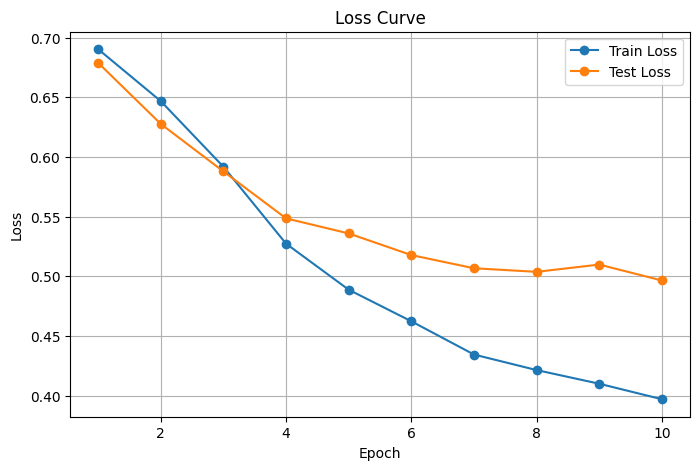

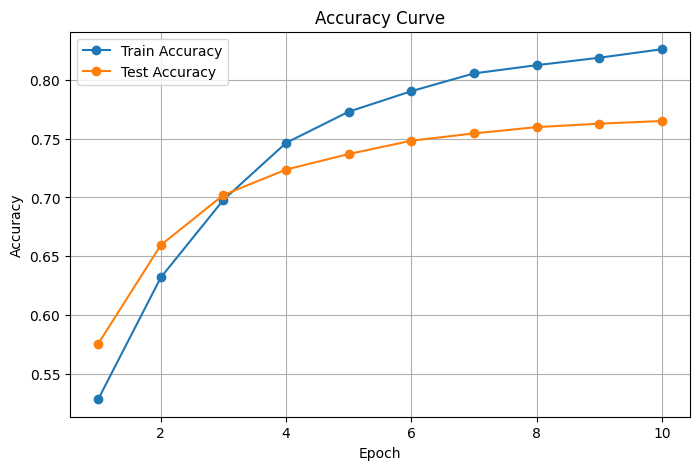

In [20]:
# x축에 사용할 에포크 번호를 생성합니다.
epochs_range = range(1, EPOCHS + 1)

# 손실 그래프를 그립니다.
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, history["test_loss"], marker="o", label="Test Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 정확도 그래프를 그립니다.
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs_range, history["test_acc"], marker="o", label="Test Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 10. 최종 평가

혼동행렬을 통해 부정/긍정 리뷰가 어떻게 분류되었는지 확인합니다.


In [22]:
# 평가 데이터 전체에 대해 최종 성능을 계산합니다.
final_loss, final_acc, final_preds, final_labels = evaluate(model, test_loader, criterion, device)

# 최종 평가 지표를 출력합니다.
print(f"최종 평가 손실: {final_loss:.4f}")
print(f"최종 평가 정확도: {final_acc * 100:.2f}%")

# F1 점수를 계산하고 출력합니다.
f1 = f1_score(final_labels, final_preds, average="binary")
print(f"최종 F1 점수: {f1 * 100:.2f}%")

# 혼동행렬을 계산하고 출력합니다.
cm = confusion_matrix(final_labels, final_preds)
print("혼동행렬:")
print(cm)

# 혼동행렬의 의미를 출력합니다.
print("혼동행렬 해석:")
print("[[실제 부정-예측 부정, 실제 부정-예측 긍정],")
print(" [실제 긍정-예측 부정, 실제 긍정-예측 긍정]]")

최종 평가 손실: 0.4965
최종 평가 정확도: 76.49%
최종 F1 점수: 76.06%
혼동행렬:
[[9782 2718]
 [3160 9340]]
혼동행렬 해석:
[[실제 부정-예측 부정, 실제 부정-예측 긍정],
 [실제 긍정-예측 부정, 실제 긍정-예측 긍정]]


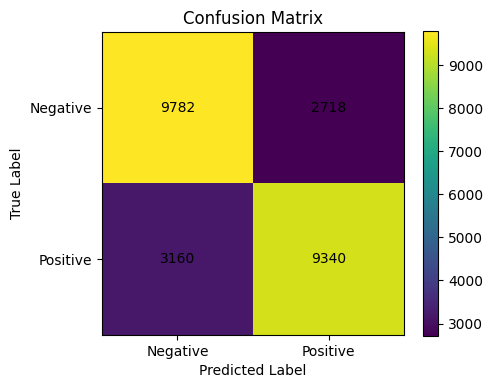

In [23]:
# 혼동행렬을 시각화합니다.
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
label_names = ["Negative", "Positive"]
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names)
plt.yticks(tick_marks, label_names)

# 각 칸에 숫자를 표시합니다.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 11. 샘플 리뷰 예측 확인

평가 데이터 중 하나를 선택하여 실제 리뷰 단어, 정답 라벨, 모델 예측 결과를 확인합니다.


In [25]:
# 확인할 평가 데이터 인덱스를 지정합니다.
sample_idx = 5

# 선택한 샘플 리뷰를 가져옵니다.
sample_text = torch.tensor(X_test[sample_idx], dtype=torch.long).unsqueeze(0).to(device)

# 선택한 샘플의 정답 라벨을 가져옵니다.
sample_label = y_test[sample_idx]

# 모델을 평가 모드로 전환합니다.
model.eval()

# 예측할 때는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
with torch.no_grad():
    # 모델이 샘플 리뷰에 대한 logit을 계산합니다.
    sample_logit = model(sample_text)

    # logit을 sigmoid 확률로 변환합니다.
    sample_prob = torch.sigmoid(sample_logit).item()

    # 확률이 0.5 이상이면 1, 아니면 0으로 예측합니다.
    sample_pred = 1 if sample_prob >= 0.5 else 0

# 샘플 리뷰를 단어로 복원합니다.
sample_review_text = decode_review(X_test[sample_idx], id_to_word)

# 샘플 리뷰와 결과를 출력합니다.
print("샘플 리뷰:")
print(sample_review_text)
print("정답 라벨:", sample_label, "(0=부정, 1=긍정)")
print(f"모델의 긍정 확률: {sample_prob:.4f}")
print("모델 예측:", sample_pred, "(0=부정, 1=긍정)")

샘플 리뷰:
??? i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figured out why disney hasn't put this movie on dvd or on vhs in rental stores at least i haven't seen any copies this is a wicked good movie and
정답 라벨: 1 (0=부정, 1=긍정)
모델의 긍정 확률: 0.6779
모델 예측: 1 (0=부정, 1=긍정)


## 12. 모델 저장과 불러오기

학습된 모델은 `state_dict` 형태로 저장하는 것이 일반적입니다. 나중에 같은 모델 구조를 만든 뒤 저장된 가중치를 불러와 다시 사용할 수 있습니다.


In [26]:
# 모델 가중치를 저장할 파일 이름을 지정합니다.
MODEL_PATH = "imdb_sentiment_lstm_adamw.pth"

# 모델의 학습된 가중치만 저장합니다.
torch.save(model.state_dict(), MODEL_PATH)
print("모델 가중치 저장 완료:", MODEL_PATH)

# 같은 구조의 새 모델 객체를 생성합니다.
loaded_model = SentimentLSTM(NUM_WORDS, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)

# 저장된 가중치를 새 모델에 불러옵니다.
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

# 새 모델을 현재 장치로 이동하고 평가 모드로 전환합니다.
loaded_model = loaded_model.to(device)
loaded_model.eval()
print("모델 가중치 불러오기 완료")

모델 가중치 저장 완료: imdb_sentiment_lstm_adamw.pth
모델 가중치 불러오기 완료


## 13. 성능 개선 실험 방향

정확도와 F1 점수를 높이려면 다음 항목을 실험할 수 있습니다.

1. `MAX_LEN`을 120 또는 200으로 늘려 더 긴 리뷰 정보를 사용합니다.
2. `EMBED_DIM`을 64 또는 128로 늘립니다.
3. `HIDDEN_DIM`을 128 또는 256으로 늘립니다.
4. `NUM_LAYERS`를 2로 설정해 LSTM을 깊게 만듭니다.
5. 양방향 LSTM을 사용해 문장을 앞뒤 방향에서 모두 읽게 합니다.
6. 학습률을 `0.0005`, `0.0003` 등으로 낮춰 봅니다.
7. 에포크 수를 늘리되 평가 손실이 증가하면 과적합을 의심합니다.
